# Master Pipeline: Smooth Hard-Coulomb SOC Estimator

This notebook is the executable research spine for the final publication phase. It keeps the science visible: zero-leakage preprocessing first, evidence plots second, constrained architecture third, and metrics/PVR certification last.

The quick training cell is intentionally small: 5 epochs on a Scenario A subset. For the full manuscript run, use the terminal commands in Section 5.


## 1. Environment Setup and Imports

Reproducibility starts before data loading. This cell fixes seeds, enables deterministic CUDA where practical, and anchors all paths to the repository root.


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Image, Markdown, display
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "src").exists():
    raise RuntimeError(f"Run this notebook from repository root. Current cwd={BASE_DIR}")
SRC_DIR = BASE_DIR / "src"
for path in [BASE_DIR, SRC_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Repository root: {BASE_DIR}")
print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Device: cuda
Seed: 42


## 2. Data Pipeline and Zero-Leakage Windowing

The final data branch is v4/v5 only. v4 enforces strict 1 Hz conversion, splits continuous profiles before windowing, and verifies zero timestamp overlap. v5_contextual adds causal anchor context after each split, so 60-second history cannot cross train/validation/test boundaries.


In [2]:
from src.preprocessing_v4 import FEATURE_COLS_V4, WINDOW, STRIDE
from src.preprocessing_v5_contextual import ANCHOR_CTX_COLS, LOOKBACK_SEC

v4_a = BASE_DIR / "data" / "processed" / "v4_scenario_A"
v4_b = BASE_DIR / "data" / "processed" / "v4_scenario_B"
v5_a = BASE_DIR / "data" / "processed" / "v5_contextual" / "scenario_A"
required_dirs = [v4_a, v4_b, v5_a]
missing_dirs = [str(path) for path in required_dirs if not path.exists()]
if missing_dirs:
    raise FileNotFoundError("Missing processed data. Run src/preprocessing_v4.py and src/preprocessing_v5_contextual.py first: " + ", ".join(missing_dirs))

def load_split(data_dir: Path, split: str):
    X = np.load(data_dir / f"X_{split}.npy").astype(np.float32, copy=False)
    y = np.load(data_dir / f"y_{split}.npy").astype(np.float32, copy=False)
    I = np.load(data_dir / f"I_unscaled_{split}.npy").astype(np.float32, copy=False)
    return X, y, I

X_train, y_train, I_train = load_split(v4_a, "train")
X_val, y_val, I_val = load_split(v4_a, "val")
X_test, y_test, I_test = load_split(v4_a, "test")
labels_test = np.load(v4_a / "temp_labels_test.npy", allow_pickle=True)

print("Scenario A v4 shapes")
print(f"  train: X={X_train.shape}, y={y_train.shape}, I={I_train.shape}")
print(f"  val  : X={X_val.shape}, y={y_val.shape}, I={I_val.shape}")
print(f"  test : X={X_test.shape}, y={y_test.shape}, I={I_test.shape}")
print(f"  temp labels: {dict(zip(*np.unique(labels_test, return_counts=True)))}")
print(f"  SOC range: train=[{y_train.min():.4f}, {y_train.max():.4f}], test=[{y_test.min():.4f}, {y_test.max():.4f}]")

sample_df = pd.DataFrame(X_train[0, :8, :], columns=FEATURE_COLS_V4)
display(Markdown("**Clean scaled feature sample (first train window, first 8 timesteps)**"))
display(sample_df)


Scenario A v4 shapes
  train: X=(15641, 100, 5), y=(15641, 100), I=(15641, 100)
  val  : X=(9084, 100, 5), y=(9084, 100), I=(9084, 100)
  test : X=(18914, 100, 5), y=(18914, 100), I=(18914, 100)
  temp labels: {'40degC': 6148, 'n10degC': 7387, 'n20degC': 5379}
  SOC range: train=[0.0000, 1.0000], test=[0.0000, 1.0000]


**Clean scaled feature sample (first train window, first 8 timesteps)**

,V_proxy,Current,Temperature,dV_proxy_dt,dI_dt
0,0.581928,0.433530,0.63424,0.499435,0.499872
1,0.582597,0.389408,0.63424,0.500293,0.455878
2,0.582048,0.353267,0.63424,0.499760,0.463859
3,0.578412,0.385257,0.63424,0.498409,0.531990
4,0.577919,0.383789,0.63424,0.499784,0.498531
5,0.575616,0.427911,0.63424,0.498992,0.544122
6,0.578145,0.382448,0.63424,0.501106,0.454537
7,0.577943,0.332388,0.63424,0.499912,0.449940


In [3]:
def metadata_summary(path: Path, filename: str):
    meta = json.loads((path / filename).read_text(encoding="utf-8"))
    verification = meta.get("verification", {})
    counts = meta.get("split_window_counts", {})
    return verification, counts

v4_verification, v4_counts = metadata_summary(v4_a, "metadata_v4.json")
v5_verification = json.loads((v5_a / "metadata_v5_contextual.json").read_text(encoding="utf-8")).get("verification", {})

print("v4 Scenario A leakage verification")
for key, value in v4_verification.items():
    print(f"  {key}: {value}")
assert all(int(value) == 0 for value in v4_verification.values())

print("\nv5_contextual Scenario A leakage verification")
for key, value in v5_verification.items():
    print(f"  {key}: {value}")
assert all(int(value) == 0 for value in v5_verification.values())


v4 Scenario A leakage verification
  train_val: 0
  train_test: 0
  val_test: 0
  train_val_key: 0
  train_test_key: 0
  val_test_key: 0

v5_contextual Scenario A leakage verification
  train_val_used_key: 0
  train_test_used_key: 0
  val_test_used_key: 0


In [4]:
audit_md = BASE_DIR / "outputs" / "data_audit_tables.md"
if not audit_md.exists():
    subprocess.run([sys.executable, str(BASE_DIR / "tools" / "generate_data_audit_tables.py")], check=True, cwd=BASE_DIR)

display(Markdown(audit_md.read_text(encoding="utf-8")))


**Table 1. Raw Data Integrity Audit**

| Temperature | Drive files | Raw rows | Dropped/NaN rows | Voltage violations (<2.5 or >4.25 V) | Current spikes (|I|>20 A) | SOC anomalies before clipping | SOC rows audited |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 40 C | 12 | 633806 | 22 | 0 | 0 | 0 | 633784 |
| 25 C | 12 | 927095 | 23 | 0 | 0 | 0 | 927072 |
| 10 C | 11 | 847097 | 34 | 0 | 0 | 0 | 847063 |
| 0 C | 11 | 778005 | 21 | 0 | 0 | 0 | 777984 |
| -10 C | 12 | 760615 | 32 | 0 | 0 | 0 | 760583 |
| -20 C | 12 | 552061 | 12 | 0 | 0 | 0 | 552049 |

**Table 2. Scenario Composition After v4 Split-Before-Windowing**

| Scenario | Temperature | Train windows | Validation windows | Test windows |
| --- | --- | --- | --- | --- |
| A | 40 C | 0 | 0 | 6148 |
| A | 25 C | 8199 | 790 | 0 |
| A | 10 C | 7442 | 675 | 0 |
| A | 0 C | 0 | 7619 | 0 |
| A | -10 C | 0 | 0 | 7387 |
| A | -20 C | 0 | 0 | 5379 |
| B | 40 C | 4245 | 448 | 1079 |
| B | 25 C | 6346 | 789 | 1712 |
| B | 10 C | 5750 | 674 | 1520 |
| B | 0 C | 5286 | 618 | 1395 |
| B | -10 C | 5107 | 597 | 1342 |
| B | -20 C | 3723 | 412 | 962 |


## 3. The Money Plots: EDA Validation

These plots are not decorative. The first shows voltage-SOC observability collapse at -20 C; the second shows dynamic EV-like current excitation and voltage sag. Existing 300 DPI PNG/PDF files are reused when present, and regenerated from `notebooks/05_q1_eda_money_plots.py` if missing.


Saved: outputs\figures\fig_q1_observability_collapse.png
Saved: outputs\figures\fig_q1_observability_collapse.pdf
Saved: outputs\figures\fig_q1_transient_dynamic_profile.png
Saved: outputs\figures\fig_q1_transient_dynamic_profile.pdf


**Observability Collapse (-20 C vs 25 C)**

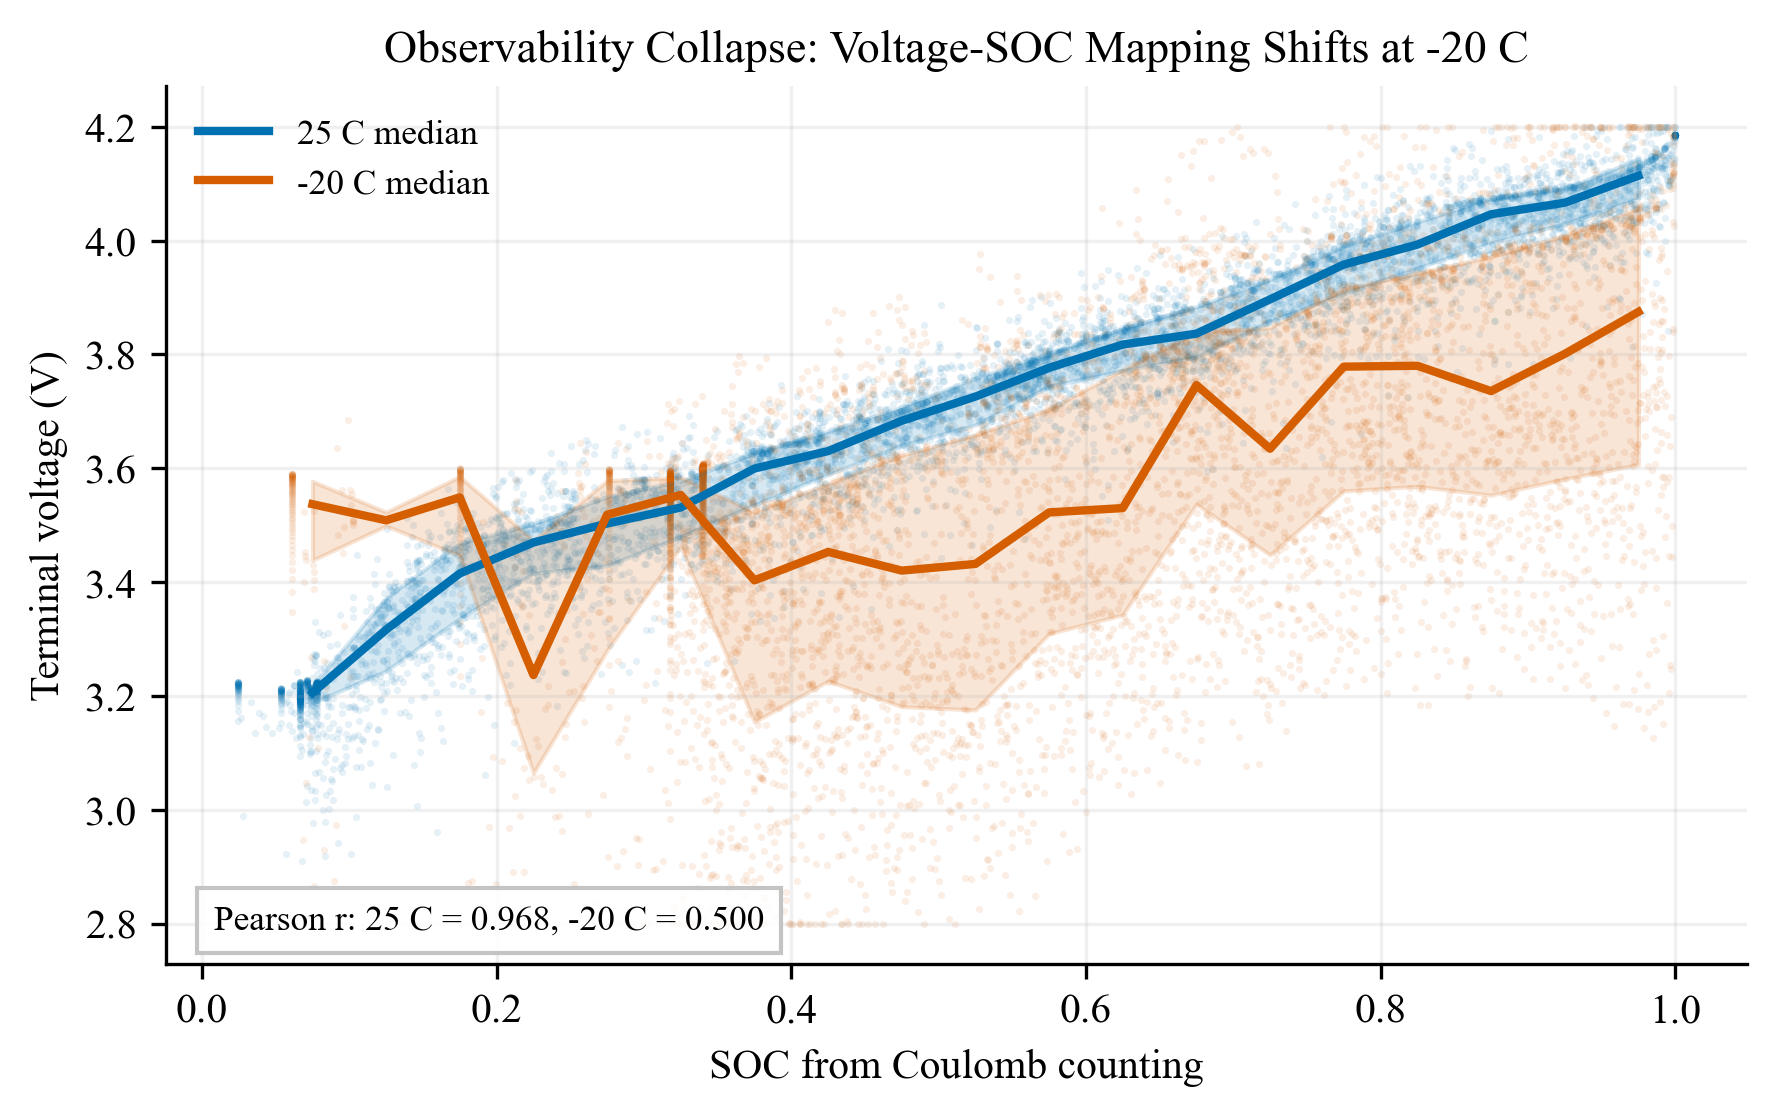

**Transient Dynamic Profile**

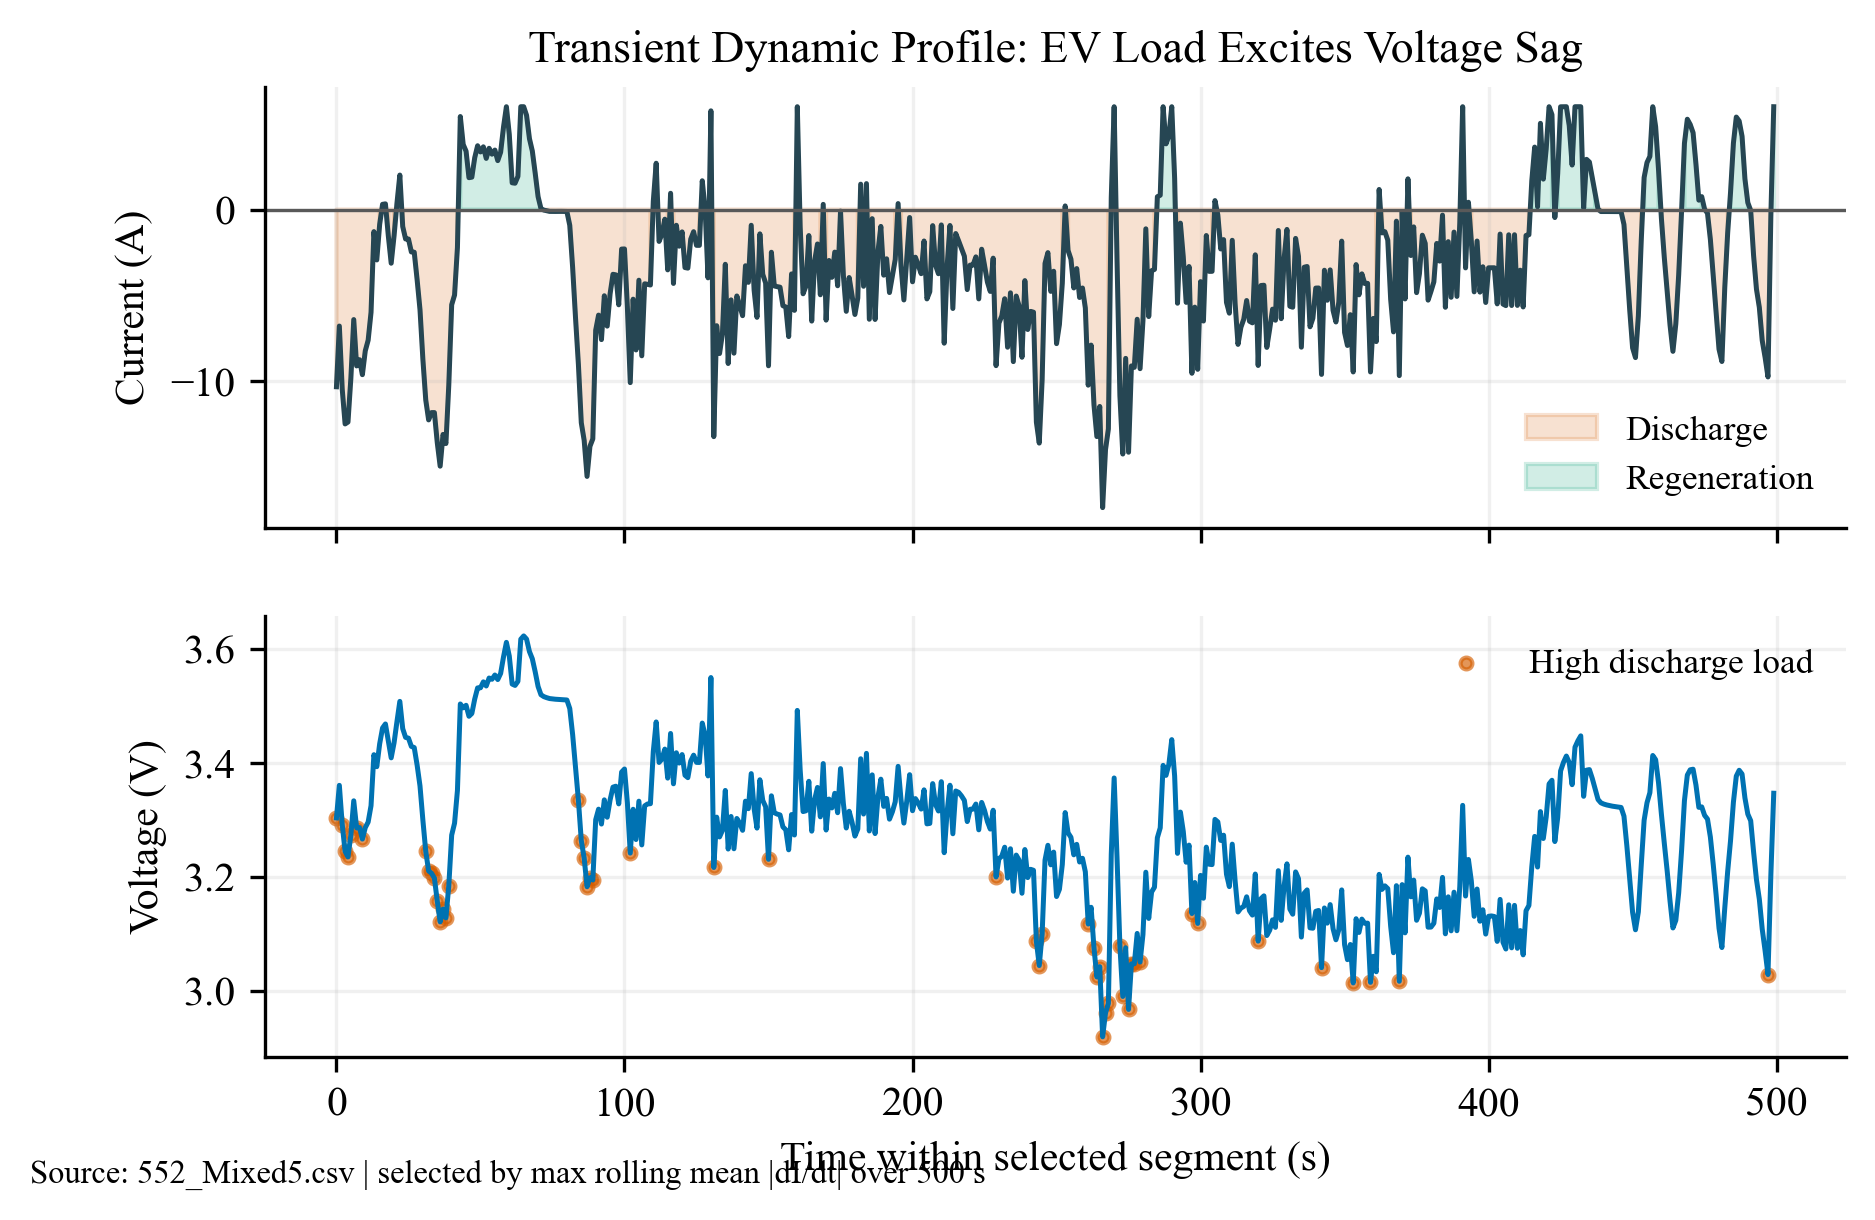

In [5]:
fig_dir = BASE_DIR / "outputs" / "figures"
plot_script = BASE_DIR / "notebooks" / "05_q1_eda_money_plots.py"
required_figs = [
    fig_dir / "fig_q1_observability_collapse.png",
    fig_dir / "fig_q1_observability_collapse.pdf",
    fig_dir / "fig_q1_transient_dynamic_profile.png",
    fig_dir / "fig_q1_transient_dynamic_profile.pdf",
]
if not all(path.exists() for path in required_figs):
    subprocess.run([sys.executable, str(plot_script)], check=True, cwd=BASE_DIR)

for path in required_figs:
    print(f"Saved: {path.relative_to(BASE_DIR)}")

display(Markdown("**Observability Collapse (-20 C vs 25 C)**"))
display(Image(filename=str(fig_dir / "fig_q1_observability_collapse.png")))
display(Markdown("**Transient Dynamic Profile**"))
display(Image(filename=str(fig_dir / "fig_q1_transient_dynamic_profile.png")))


## 4. Smooth Hard-Coulomb Architecture

The constraint is structural. The sequence model emits magnitude logits, not signed deltas. A sigmoid maps each logit to a differentiable fraction of the current-dependent Coulomb envelope, while `torch.where` routes the sign from the measured current. This keeps PVR at 0.00% by construction and avoids the dead-gradient behavior of hard clamping raw deltas.


In [6]:
Q_NOMINAL = 3.0
CURRENT_THRESHOLD = 0.05
NUM_INPUTS = 5
NUM_FILTERS = 64
KERNEL_SIZE = 7
DROPOUT = 0.2
DILATION_RATES = [1, 2, 4, 8]

class SmoothHardCoulombConstraint(nn.Module):
    def __init__(self, q_nominal=Q_NOMINAL, dt=1.0, safety_factor=1.5, threshold=CURRENT_THRESHOLD, eps=1e-6):
        super().__init__()
        self.threshold = float(threshold)
        self.safety_factor = float(safety_factor)
        self.eps = float(eps)
        self.gamma = float(dt) / (float(q_nominal) * 3600.0)

    @property
    def gamma_factor(self):
        return self.gamma * self.safety_factor

    def forward(self, delta_logits, current_seq, anchor_logit):
        I = current_seq.unsqueeze(-1)
        limit = I.abs() * self.gamma_factor
        mag_frac = torch.sigmoid(delta_logits)
        zero = torch.zeros_like(delta_logits)

        delta = torch.where(I < -self.threshold, -limit * mag_frac, zero)
        delta = torch.where(I > self.threshold, limit * mag_frac, delta)

        cumulative = torch.cumsum(delta, dim=1)
        lo = (-cumulative.min(dim=1).values).clamp(0.0, 1.0)
        hi = (1.0 - cumulative.max(dim=1).values).clamp(0.0, 1.0)
        width = (hi - lo).clamp_min(self.eps)
        soc_anchor = lo + width * torch.sigmoid(anchor_logit)
        soc_pred = soc_anchor.unsqueeze(1) + cumulative
        return soc_pred, delta

class HardCoulombLSTM(nn.Module):
    def __init__(self, num_inputs=NUM_INPUTS, hidden_size=64, num_layers=2, dropout=0.2, safety_factor=1.5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_inputs,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.delta_head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        self.anchor_head = nn.Sequential(nn.Linear(hidden_size, 16), nn.ReLU(), nn.Linear(16, 1))
        self.hard_constraint = SmoothHardCoulombConstraint(safety_factor=safety_factor)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0.0)
                n = param.size(0)
                param.data[n // 4:n // 2].fill_(1.0)
        for head in [self.delta_head, self.anchor_head]:
            for layer in head:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
                    nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.delta_head[-1].weight, gain=0.1)
        nn.init.zeros_(self.delta_head[-1].bias)
        nn.init.xavier_uniform_(self.anchor_head[-1].weight, gain=0.1)
        nn.init.zeros_(self.anchor_head[-1].bias)

    def forward(self, x, current_seq, return_delta=False):
        h, _ = self.lstm(x)
        delta_logits = self.delta_head(h)
        anchor_logit = self.anchor_head(h[:, 0, :])
        soc_pred, delta = self.hard_constraint(delta_logits, current_seq, anchor_logit)
        if return_delta:
            return soc_pred, delta
        return soc_pred

def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

model_check = HardCoulombLSTM()
print(f"HardCoulombLSTM params: {count_parameters(model_check):,}")
print(model_check.hard_constraint)


HardCoulombLSTM params: 54,626
SmoothHardCoulombConstraint()


In [7]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.norm1 = nn.LayerNorm(n_outputs)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.norm2 = nn.LayerNorm(n_outputs)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu_out = nn.ReLU()
        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity="relu")
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight, nonlinearity="relu")

    def forward(self, x):
        out = self.chomp1(self.conv1(x))
        out = self.dropout1(self.relu1(self.norm1(out.transpose(1, 2)).transpose(1, 2)))
        out = self.chomp2(self.conv2(out))
        out = self.dropout2(self.relu2(self.norm2(out.transpose(1, 2)).transpose(1, 2)))
        res = x if self.downsample is None else self.downsample(x)
        return self.relu_out(out + res)

class ContextualHardCoulombTCN(nn.Module):
    def __init__(self, num_inputs=NUM_INPUTS, anchor_ctx_dim=len(ANCHOR_CTX_COLS), num_filters=NUM_FILTERS,
                 kernel_size=KERNEL_SIZE, dropout=DROPOUT, dilation_rates=None, safety_factor=1.5):
        super().__init__()
        rates = list(DILATION_RATES if dilation_rates is None else dilation_rates)
        layers = []
        for idx, dilation in enumerate(rates):
            in_channels = num_inputs if idx == 0 else num_filters
            layers.append(TemporalBlock(in_channels, num_filters, kernel_size, 1, dilation, dropout))
        self.tcn = nn.Sequential(*layers)
        self.delta_head = nn.Sequential(nn.Linear(num_filters, 32), nn.ReLU(), nn.Linear(32, 1))
        self.anchor_ctx_encoder = nn.Sequential(nn.Linear(anchor_ctx_dim, 32), nn.ReLU(), nn.LayerNorm(32))
        self.anchor_head = nn.Sequential(nn.Linear(num_filters + 32, 32), nn.ReLU(), nn.Linear(32, 1))
        self.hard_constraint = SmoothHardCoulombConstraint(safety_factor=safety_factor)
        self.receptive_field = 1 + 2 * (kernel_size - 1) * sum(rates)
        self._init_heads()

    def _init_heads(self):
        for module in [self.delta_head, self.anchor_ctx_encoder, self.anchor_head]:
            for layer in module:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
                    nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.delta_head[-1].weight, gain=0.1)
        nn.init.zeros_(self.delta_head[-1].bias)
        nn.init.xavier_uniform_(self.anchor_head[-1].weight, gain=0.1)
        nn.init.zeros_(self.anchor_head[-1].bias)

    def forward(self, x_seq, current_seq, anchor_ctx):
        hidden = self.tcn(x_seq.transpose(1, 2)).transpose(1, 2)
        delta_logits = self.delta_head(hidden)
        context_embedding = self.anchor_ctx_encoder(anchor_ctx)
        anchor_input = torch.cat([hidden[:, 0, :], context_embedding], dim=-1)
        anchor_logit = self.anchor_head(anchor_input)
        soc_pred, delta = self.hard_constraint(delta_logits, current_seq, anchor_logit)
        return soc_pred, delta

tcn_check = ContextualHardCoulombTCN()
print(f"ContextualHardCoulombTCN params: {count_parameters(tcn_check):,}")
print(f"TCN receptive field: {tcn_check.receptive_field} steps")


ContextualHardCoulombTCN params: 210,658
TCN receptive field: 181 steps


## 5. Training and Evaluation: Core Engine

This cell runs a fast proof-of-concept: 5 epochs, Scenario A subset, small LSTM hidden size. It verifies the forward/backward path and PVR invariant without consuming publication-scale compute.

For full manuscript reproduction, run:

```bash
python src/preprocessing_v4.py
python src/preprocessing_v5_contextual.py
python src/sprint48_train_scenario_A.py
python src/sprint48_train_scenario_B.py
python src/sprint50_train_contextual.py
python src/sprint52_tcn_redemption.py
python src/sprint48_evaluate_all.py
```

To make this notebook perform a heavier run, increase `FAST_EPOCHS` toward 100 and set `FAST_TRAIN_WINDOWS = None`.


In [8]:
FAST_EPOCHS = 5
FAST_TRAIN_WINDOWS = 1024
FAST_VAL_WINDOWS = 512
BATCH_SIZE_FAST = 128
LR_FAST = 1e-3

rng = np.random.default_rng(SEED)
train_idx = rng.choice(len(X_train), size=min(FAST_TRAIN_WINDOWS, len(X_train)), replace=False)
val_idx = rng.choice(len(X_val), size=min(FAST_VAL_WINDOWS, len(X_val)), replace=False)

train_ds = TensorDataset(
    torch.from_numpy(X_train[train_idx]),
    torch.from_numpy(y_train[train_idx]),
    torch.from_numpy(I_train[train_idx]),
)
val_ds = TensorDataset(
    torch.from_numpy(X_val[val_idx]),
    torch.from_numpy(y_val[val_idx]),
    torch.from_numpy(I_val[val_idx]),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_FAST, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_FAST, shuffle=False, num_workers=0)

proof_model = HardCoulombLSTM(hidden_size=32, num_layers=1, dropout=0.0).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(proof_model.parameters(), lr=LR_FAST, weight_decay=1e-4)

history = []
for epoch in range(1, FAST_EPOCHS + 1):
    proof_model.train()
    running = 0.0
    for Xb, yb, Ib in tqdm(train_loader, desc=f"fast proof epoch {epoch}/{FAST_EPOCHS}", leave=False):
        Xb = Xb.to(DEVICE)
        yb = yb.to(DEVICE).unsqueeze(-1)
        Ib = Ib.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = proof_model(Xb, Ib)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(proof_model.parameters(), max_norm=1.0)
        optimizer.step()
        running += float(loss.item())

    proof_model.eval()
    val_running = 0.0
    with torch.no_grad():
        for Xb, yb, Ib in val_loader:
            pred = proof_model(Xb.to(DEVICE), Ib.to(DEVICE))
            val_running += float(criterion(pred, yb.to(DEVICE).unsqueeze(-1)).item())
    record = {
        "epoch": epoch,
        "train_loss": running / max(len(train_loader), 1),
        "val_loss": val_running / max(len(val_loader), 1),
    }
    history.append(record)
    print(f"epoch {epoch:02d}: train={record['train_loss']:.6f}, val={record['val_loss']:.6f}")

display(pd.DataFrame(history))


fast proof epoch 1/5:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 01: train=0.073539, val=0.096770


fast proof epoch 2/5:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 02: train=0.072910, val=0.097031


fast proof epoch 3/5:   0%|          | 0/8 [00:00<?, ?it/s]

...

fast proof epoch 4/5:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 04: train=0.071407, val=0.097928


fast proof epoch 5/5:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 05: train=0.070574, val=0.098724


,epoch,train_loss,val_loss
0,1,0.073539,0.096770
1,2,0.072910,0.097031
2,3,0.072212,0.097396
3,4,0.071407,0.097928
4,5,0.070574,0.098724


In [9]:
def evaluate_model(model, X, y, I, batch_size=512):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y), torch.from_numpy(I))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    preds, deltas = [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb, Ib in loader:
            pred, delta = model(Xb.to(DEVICE), Ib.to(DEVICE), return_delta=True)
            preds.append(pred.detach().cpu().numpy().squeeze(-1))
            deltas.append(delta.detach().cpu().numpy().squeeze(-1))
    return np.concatenate(preds, axis=0), np.concatenate(deltas, axis=0)

def metrics_from_arrays(y_true, y_pred, current, delta=None, labels=None):
    err = y_pred - y_true
    out = {
        "rmse_full_pct": float(np.sqrt(np.mean(err ** 2)) * 100.0),
        "maxe_full_pct": float(np.max(np.abs(err)) * 100.0),
    }
    discharge = current < -CURRENT_THRESHOLD
    if delta is None:
        delta_check = np.diff(y_pred, axis=1)
        discharge_check = current[:, 1:] < -CURRENT_THRESHOLD
    else:
        delta_check = delta
        discharge_check = discharge
    violations = (delta_check > 0.0) & discharge_check
    discharge_steps = int(discharge_check.sum())
    out["pvr_pct"] = 0.0 if discharge_steps == 0 else float(violations.sum() / discharge_steps * 100.0)
    out["pvr_violations"] = int(violations.sum())
    out["pvr_discharge_steps"] = discharge_steps
    if labels is not None:
        n20 = labels == "n20degC"
        if n20.any():
            n20_err = y_pred[n20] - y_true[n20]
            out["n20_rmse_pct"] = float(np.sqrt(np.mean(n20_err ** 2)) * 100.0)
            out["n20_maxe_pct"] = float(np.max(np.abs(n20_err)) * 100.0)
            out["n20_windows"] = int(n20.sum())
    return out

proof_pred, proof_delta = evaluate_model(proof_model, X_test, y_test, I_test)
proof_metrics = metrics_from_arrays(y_test, proof_pred, I_test, proof_delta, labels_test)
display(pd.DataFrame([proof_metrics]).T.rename(columns={0: "fast_proof"}))
assert proof_metrics["pvr_violations"] == 0


,fast_proof
rmse_full_pct,2.678643e+01
maxe_full_pct,5.418178e+01
pvr_pct,0.000000e+00
pvr_violations,0.000000e+00
pvr_discharge_steps,1.306543e+06
n20_rmse_pct,2.343678e+01
n20_maxe_pct,4.709249e+01
n20_windows,5.379000e+03


## 6. Final Metrics and PVR Certification

The fast proof above proves notebook execution. This final cell reads the completed full-run ledgers from Sprint 48, Sprint 50, and Sprint 52. These are the publication-scale metrics generated after the Smooth Hard-Coulomb refactor.


In [10]:
def read_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))

rows = []

s48 = read_json(BASE_DIR / "outputs" / "v7_final" / "sprint48_evaluation_results.json")
for item in s48:
    metrics = item["metrics"]
    rows.append({
        "Branch": "Sprint48",
        "Scenario/Target": item["scenario"],
        "Model": item["model_name"],
        "RMSE_full_%": metrics["rmse_full_pct"],
        "MaxE_full_%": metrics["maxe_full_pct"],
        "PVR_%": metrics["pvr_pct"],
        "Violations": metrics["pvr_violations"],
        "Windows": metrics["n_windows"],
    })

s50 = read_json(BASE_DIR / "outputs" / "v5_contextual" / "sprint50_contextual" / "sprint50_contextual_results.json")
for item in s50["scientific_test"]:
    rows.append({
        "Branch": "Sprint50",
        "Scenario/Target": "n20degC",
        "Model": item["label"],
        "RMSE_full_%": item["full_rmse_pct"],
        "MaxE_full_%": item["full_maxe_pct"],
        "PVR_%": item["pvr_pct"],
        "Violations": item["pvr_violations"],
        "Windows": item["n_windows"],
    })

s52 = read_json(BASE_DIR / "outputs" / "v8_tcn_redemption" / "sprint52" / "sprint52_tcn_redemption_results.json")
for item in s52["results"]:
    metrics = item["metrics"]
    rows.append({
        "Branch": "Sprint52",
        "Scenario/Target": item.get("target_temp", item.get("scenario", "unknown")),
        "Model": item["model"],
        "RMSE_full_%": metrics["rmse_full_pct"],
        "MaxE_full_%": metrics["maxe_full_pct"],
        "PVR_%": metrics["pvr_pct"],
        "Violations": metrics["pvr_violations"],
        "Windows": metrics["n_windows"],
    })

metrics_df = pd.DataFrame(rows)
for col in ["RMSE_full_%", "MaxE_full_%", "PVR_%"]:
    metrics_df[col] = metrics_df[col].astype(float).round(4)
display(metrics_df)

hard_rows = metrics_df[metrics_df["Model"].str.contains("HardCoulomb|Hard-Coulomb|HC-LSTM", regex=True)]
assert (hard_rows["Violations"] == 0).all(), hard_rows
assert (hard_rows["PVR_%"] == 0.0).all(), hard_rows

n20_rows = metrics_df[metrics_df["Scenario/Target"].astype(str).str.contains("n20degC", regex=False)]
display(Markdown("**-20 C final RMSE/MaxE rows**"))
display(n20_rows)

display(Markdown("# **Physics Violation Rate (PVR): 0.00% - Invariant Confirmed.**"))


,Branch,Scenario/Target,Model,RMSE_full_%,MaxE_full_%,PVR_%,Violations,Windows
0,Sprint48,scenario_A,VanillaLSTM,13.3712,51.0242,49.9694,646223,18914
1,Sprint48,scenario_A,HardCoulombLSTM,12.7107,55.1126,0.0000,0,18914
2,Sprint48,scenario_B,VanillaLSTM,7.2806,48.7994,41.0552,147515,8010
3,Sprint48,scenario_B,HardCoulombLSTM,8.5667,34.9985,0.0000,0,8010
4,Sprint50,n20degC,HC-LSTM Empty Anchor Ctx,17.0909,52.7044,0.0000,0,5289
5,Sprint50,n20degC,+OCV-rest only,13.9408,47.1837,0.0000,0,5289
6,Sprint50,n20degC,+History only,22.8942,62.1314,0.0000,0,5289
7,Sprint50,n20degC,+OCV-rest + History,17.4968,52.9069,0.0000,0,5289
8,Sprint52,scenario_A,HardCoulombTCN,11.4587,46.7298,0.0000,0,18914
9,Sprint52,scenario_B,HardCoulombTCN,8.5823,39.4864,0.0000,0,8010


**-20 C final RMSE/MaxE rows**

,Branch,Scenario/Target,Model,RMSE_full_%,MaxE_full_%,PVR_%,Violations,Windows
4,Sprint50,n20degC,HC-LSTM Empty Anchor Ctx,17.0909,52.7044,0.0,0,5289
5,Sprint50,n20degC,+OCV-rest only,13.9408,47.1837,0.0,0,5289
6,Sprint50,n20degC,+History only,22.8942,62.1314,0.0,0,5289
7,Sprint50,n20degC,+OCV-rest + History,17.4968,52.9069,0.0,0,5289
10,Sprint52,n20degC,ContextualHardCoulombTCN,19.8784,47.5308,0.0,0,5289


# **Physics Violation Rate (PVR): 0.00% - Invariant Confirmed.**